In [1]:
%pylab inline
import os,sys,pickle,yaml
from builtins import sum as bsum
from importlib import reload
plt.style.use('default')
os.environ["FISHER_PLUMES"] = os.path.join(os.environ["GIT"],"fisher-plumes")
os.chdir(os.environ["FISHER_PLUMES"])



Populating the interactive namespace from numpy and matplotlib


In [2]:
try:
    UNITS
except NameError:
    import units; reload(units); UNITS = units.UNITS;


In [3]:
import boulder;   reload(boulder)
import crick;     reload(crick)
import fisher_plumes_tools as fpt;      reload(fpt)
import fisher_plumes_figs as fpf;       reload(fpf)
import fisher_plumes as fp;             reload(fp)
import proc; reload(proc);
import assumptions as assm;



INFO:crick:Simulation data available for:


INFO:crick:crimgrid_w1                                     : y0 - y9 (16 datasets)


INFO:crick:crimgrid_w2                                     : y0 - y9 (16 datasets)


INFO:crick:crimgrid_w3                                     : y0 - y9 (16 datasets)


INFO:crick:crimgrid_w4                                     : y0 - y9 (16 datasets)


...

INFO:crick:n16T                                            : Y0.440 - Y0.560 (16 datasets)


INFO:crick:n16Tslow                                        : Y0.440 - Y0.560 (16 datasets)


INFO:crick:n16Tslow_45deg                                  : X0.418Y0.458 - X0.502Y0.542 (16 datasets)


INFO:crick:n16Tslow_X                                      : X0.400 - X0.648 (32 datasets)


INFO:surrogate:Surrogate simulation data available for: ['no_info', 'one_info', 'two_info', 'high', 'spike_and_slab', 'blue', 'red', 'all_equal']


In [4]:
# Get the fp_data file that we want to plot
matches = proc.find_registry_matches(init_filter = {"sim_name":"boulder16",
                                                    #"which_coords":(0.45, 0.5) * UNITS.m
                                                    },
                                     compute_filter = {"window_shape":"hann", "window_length": 1 * UNITS.s, "dmax_um":"1 * PITCH"})
print(f"Found {len(matches)} matches.")


                    proc 2024/07/29 09:07:54     INFO: No registry given. Loading registry from proc/registry.p.


                    proc 2024/07/29 09:07:55     INFO: No coords in init_filter.


Found 9 matches.


In [43]:
sorted_matches = sorted(matches, key = lambda x: -100*x["init"]["which_coords"][0][1].magnitude + x["init"]["which_coords"][0][0].magnitude)
[s["init"]["which_coords"][0] for s in sorted_matches]

[array([0.35, 0.7 ]) <Unit('meter')>,
 array([0.4, 0.7]) <Unit('meter')>,
 array([0.45, 0.7 ]) <Unit('meter')>,
 array([0.35, 0.5 ]) <Unit('meter')>,
 array([0.4, 0.5]) <Unit('meter')>,
 array([0.45, 0.5 ]) <Unit('meter')>,
 array([0.35, 0.3 ]) <Unit('meter')>,
 array([0.4, 0.3]) <Unit('meter')>,
 array([0.45, 0.3 ]) <Unit('meter')>]

In [44]:
[x.logger.setLevel(logging.WARN) for x in [boulder, fp]]
full_file_names = [x["file"] for x in sorted_matches]
fp_data = [pickle.load(open(full_file_name, 'rb'))["results"] for full_file_name in full_file_names]
F       = [fp.FisherPlumes(f) for f in fp_data]
suffixes = [ffn.split("/")[-1] for ffn in full_file_names] # The pickle file name
prefixes = ["/".join(ffn.split("/")[:-1]) for ffn in full_file_names] # e.g. proc/bw.3 

# Are the distributions the same from each source?

In [74]:
def plot_loc_ind1(F, results, do_colorbar = False, ax = None, do_grid = False, xlab_pos = -1, xt_fontsize = 8, do_xlab=True, max_xlab=10):
    vec,ifreqs,keys = assm.LocationIndependence.results_to_vec(results["results"]["location_independence"])
    if ax: plt.sca(ax)
    vals = vec.copy()
    vals[vals == 0] = np.nan
    matshow(-log10(vals), vmin=0, vmax=3, cmap='gnuplot', fignum=False);
    axis("auto")
    src1 = np.array([k.src1 for k in keys[0]])
    assert list(src1) == sorted(src1)
    unique_src1 = sorted(np.unique(src1))
    axis('auto')
    
    xt_loc = np.where(np.diff(src1) > 0)[0] + 0.5
    # I don't want the major ticks to be labeld, so I'll set the labels to empty strings.
    xt_loc1 = np.array([0] + list(xt_loc) + [len(src1)])
    midpoints = (xt_loc1[1:] + xt_loc1[:-1]) / 2
    xticks(xt_loc, [""]*len(xt_loc))
    for i, mid in enumerate(midpoints):
        do_xlab and i <= max_xlab and text(mid, xlab_pos, f"{unique_src1[i]:g}", ha='center', fontsize=xt_fontsize)
    xlabel(f"First source", fontsize=12)

    # Turn the grid on, but only for the x-ticks, and using a dotted line.
    do_grid and grid(axis='x', linestyle=':', color='w')
    
    yt = gca().get_yticks()
    yt = yt[(0 <= yt)* (yt< len(ifreqs))]
    yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
    yticks(yt, yt_freqs)
    ylabel("Frequency (Hz)", fontsize=12)

    if do_colorbar:
        cax = colorbar().ax
        cax.set_yticks([0.,1.,2.,3.])
        yt = cax.get_yticks()
        cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
        cax.set_ylabel("p-value")
        # Set the position of the label to the left of the colorbar
        cax.yaxis.set_label_position('left')
    return gca()
        

In [75]:
data_file = prefixes[0] + "/test_assm/test_assm_loc_ind/" + suffixes[0]
results = pickle.load(open(data_file, 'rb'))

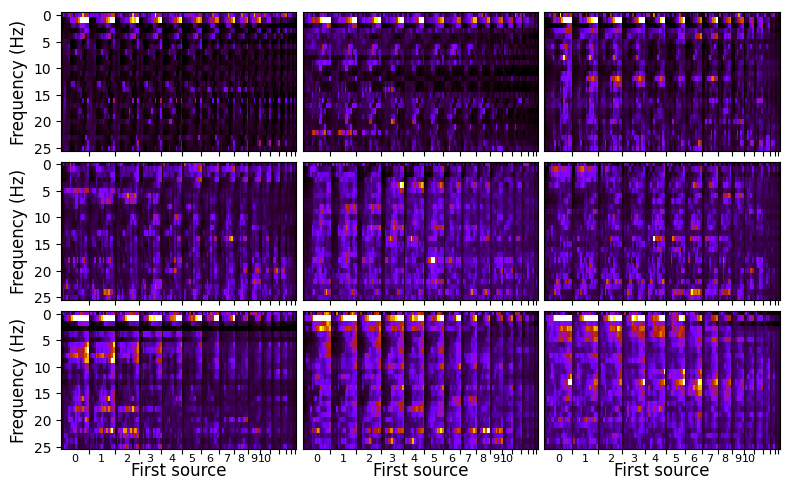

In [87]:
figure(figsize=(8,5))
for i, (pfx, sfx) in enumerate(zip(prefixes, suffixes)):
    ax = subplot(3,3,i+1)
    data_file = pfx + "/test_assm/test_assm_loc_ind/" + sfx
    results = pickle.load(open(data_file, 'rb'))
    ax = plot_loc_ind1(F[i], results, ax = ax,
                       do_grid = False,
                       xlab_pos = 27.75,
                       max_xlab=10,
                       do_xlab = i>5,
                       do_colorbar = 0*(i==5),
                       )
    ax.tick_params(top=False)
    if (i < 6):
        xlabel("")
    else:
        xlabel("First source", fontsize=12, labelpad=5)
    
    (i % 3) and (ylabel(""), yticks([]))
tight_layout(h_pad=0.1,w_pad=0.1)
savefig("figs/loc_ind_multi.png", dpi=300, bbox_inches='tight')
savefig("figs/loc_ind_multi.pdf", bbox_inches='tight')    

# Are the distributions from each source gaussian?

In [110]:
def plot_gauss_coefs1(F, results, ax = None, do_colorbar = False):
    vec,ifreqs,keys = assm.GaussianCoefs.results_to_vec(results["results"]["gaussian_coefs"])
    ax is None and figure(figsize=(8,5))
    vals = vec.copy()
    vals[vals == 0] = np.nan
    matshow(-log10(vals), vmin=0, vmax=3, cmap='gnuplot', fignum=False);
    #axis("auto")
    src1 = np.array([k.src1 for k in keys[0]])
    assert list(src1) == sorted(src1)
    axis('auto')
    gca().set_aspect(0.8)
    
    xlabel(f"Source Index", fontsize=12)
    gca().xaxis.set_ticks_position('bottom')
    # Turn the grid on, but only for the x-ticks, and using a dotted line.
    
    yt = gca().get_yticks()
    yt = yt[(0 <= yt)* (yt< len(ifreqs))]
    yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
    yticks(yt, yt_freqs)
    ylabel("Frequency (Hz)", fontsize=12)

    ax.tick_params(axis="x", labelsize=8)
    if (i < 6):
        xlabel("")
        gca().set_xticklabels([])
    else:
        xlabel("Source index", fontsize=12, labelpad=5)
    
    (i % 3) and (ylabel(""), yticks([]))
    
    if do_colorbar:
        # Make a narrow colorbar 
        cax = colorbar(shrink=0.5, aspect=20).ax
        cax.set_yticks([0.,1.,2.,3.])
        yt = cax.get_yticks()
        cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
        cax.set_ylabel("p-value")

    return gca()
    

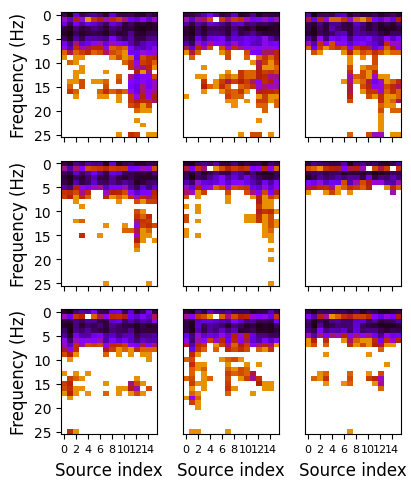

In [117]:
figure(figsize=(4.5,5))
for i, (pfx, sfx) in enumerate(zip(prefixes, suffixes)):
    ax = subplot(3,3,i+1)
    data_file = pfx + "/test_assm/test_assm_gauss_coefs/" + sfx
    results = pickle.load(open(data_file, 'rb'))
    ax = plot_gauss_coefs1(F[i], results, ax = ax,
                       do_colorbar = False,
                       )
tight_layout(h_pad=1,w_pad=0)
savefig("figs/gauss_coefs_multi.png", dpi=300, bbox_inches='tight')
savefig("figs/gauss_coefs_multi.pdf", bbox_inches='tight')    



In [347]:

data_file = "proc/bw.1/test_assm/test_assm_gauss_coefs/" + suffix
results = pickle.load(open(data_file, 'rb'))

<ipython-input-375-062ce939f607>:2: RuntimeWarning: divide by zero encountered in log10
  matshow(-log10(vec), vmin=0, vmax=3, cmap='gnuplot');


[0. 1. 2. 3.]


<Figure size 800x500 with 0 Axes>

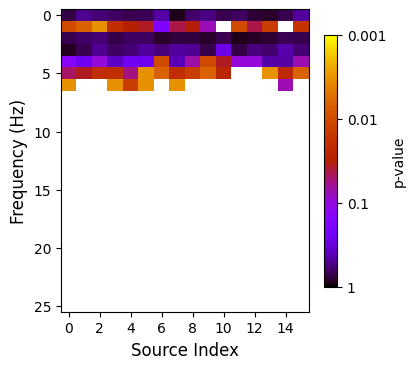

In [375]:
# Set the position of the label to the left of the colorbar
savefig("figs/gauss_coefs_multi.png", dpi=300, bbox_inches='tight')


# Are the distributions from each source stationary?

In [475]:
wc_safe = lambda x: 1 if allclose(x,0) else wilcoxon(x).pvalue

In [476]:
data_file = "proc/bw.1/test_assm/test_assm_stationarity/" + suffix
results = pickle.load(open(data_file, 'rb'))

In [420]:
vec,ifreqs,keys = assm.Stationarity.results_to_vec(results["results"]["stationarity"])

In [441]:
vals = vec.copy()
for i in range(vals.shape[0]):
    vals[i][:,-1] = wc_safe(vec[i,:,-1])

In [445]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

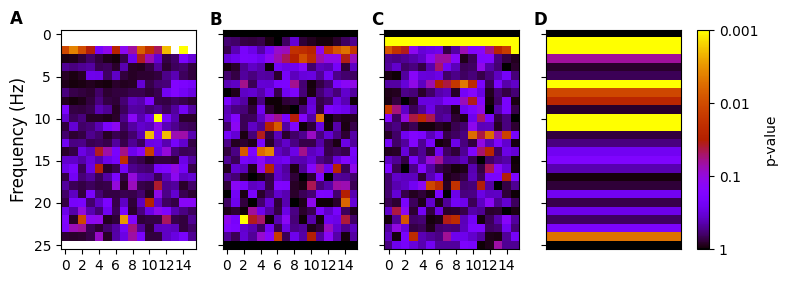

In [478]:
figure(figsize=(8,5))
ax = []
for i in range(4):
    ax.append(subplot(1,4,i+1))
    v = vals[:,:,i].copy()
    v[v == 0] = nan
    matshow(-log10(v),vmin=0,vmax=3,fignum=False, cmap='gnuplot')
    i > 0 and setp(ax[-1].get_yticklabels(), visible=False)
    i == 3 and ax[-1].set_xticks([])
    ax[-1].xaxis.set_ticks_position('bottom')

yt = ax[0].get_yticks()
yt = yt[(0 <= yt)* (yt< len(ifreqs))]
yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
ax[0].set_yticks(yt, yt_freqs)
ax[0].set_ylabel("Frequency (Hz)", fontsize=12)    
# Get the position of the last axis
pos = ax[-1].get_position()
# Create a new axis for the colorbar
cax = gcf().add_axes([pos.x1 + 0.02, pos.y0, 0.015, pos.height])
# Append a new axis for the colorbar with a specified width
colorbar(cax=cax).set_label("p-value")
cax.set_yticks([0.,1.,2.,3.])
cax.set_yticklabels([f"{10**-yti:g}" for yti in cax.get_yticks()])
fpft.label_axes(ax, "ABCD", fontweight='bold', fontsize=12, dy=0.01,dx=[0]+[-0.01]*3)
savefig("figs/stationarity_multi.png", dpi=300, bbox_inches='tight')
    

<Figure size 640x480 with 0 Axes>

# Checking whether joint distributions only depend on the distance between sources.

In [62]:
data_file = "proc/bw.1/test_assm/test_assm_joint_dist/" + suffix
results = pickle.load(open(data_file, 'rb'))


0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3, 3.3, 3.6, 3.9, 4.2, [0. 1. 2. 3.]


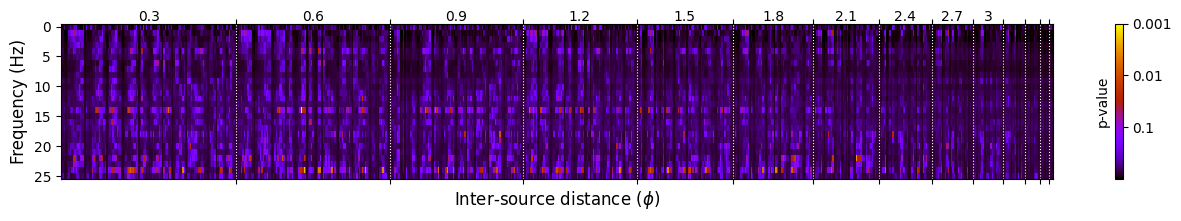

In [164]:
vec,ifreqs,keys = assm.JointDist.results_to_vec(results["results"]["joint_dist"])
dists = np.array([k.dist for k in keys[0]])
assert list(dists) == sorted(dists)
unique_dists = sorted(np.unique(dists))
vals = vec.reshape((-1, len(dists)))
vals[vals == 0] = np.nan
matshow(-log10(vals), cmap='gnuplot');
axis('auto')
yt = gca().get_yticks()
valid_yt = [int(yti) for yti in yt if yti in ifreqs]
freqs = F.inds2freqs(valid_yt)
yticks(valid_yt, [f"{f.to(UNITS.Hz).magnitude:g}" for f in freqs])
ylabel("Frequency (Hz)", fontsize=12)
# Each column is a pair of sources being compared.
# These will be in blocks sorted by the distance between the sources.
# So e.g. the first N_1 columns will be at the  minimum distance, the next N_2 columns will be at the next largest distance, etc.
# I want major ticks to be at the start of each block.
xt_loc = np.where(np.diff(dists) > 0)[0] + 0.5
# I don't want the major ticks to be labeld, so I'll set the labels to empty strings.
xt_loc1 = np.array([0] + list(xt_loc) + [len(dists)])
midpoints = (xt_loc1[1:] + xt_loc1[:-1]) / 2
xticks(xt_loc, [""]*len(xt_loc))
for i, mid in enumerate(midpoints):
    dist_um = unique_dists[i]
    dist_pitch = (dist_um * UNITS.um).to(F.pitch).magnitude
    print(f"{dist_pitch:g}", end = ", ")
    (dist_pitch < 3.1) and text(mid, -1, f"{dist_pitch:g}", ha='center', fontsize=10 if dist_pitch <= 3.4 else 6)
xlabel(f"Inter-source distance ({fpf.pitch_sym})", fontsize=12)
# Turn the grid on, but only for the x-ticks, and using a dotted line.
grid(axis='x', linestyle=':', color='w')

cax = colorbar().ax
yt = cax.get_yticks()
print(yt)
cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
cax.set_ylabel("p-value")
# Set the position of the label to the left of the colorbar
cax.yaxis.set_label_position('left')
savefig("figs/joint_dist_multi.png", dpi=300, bbox_inches='tight')

# Checking whether the conditional distribution of coefficients is Gaussian

In [286]:
data_file = "proc/bw.1/test_assm/test_assm_cond_gauss/" + suffix
results = pickle.load(open(data_file, 'rb'))
spec = utils.load_yaml(results["test_assm_spec"])
vec,ifreqs,keys,bad_keys = assm.ConditionalGaussian.results_to_vec(results["results"]["cond_gauss"], n_bins = spec["cond_gauss"]["n_bins"],n_trials = spec["cond_gauss"]["n_trials"], min_count_per_bin = 10)


             assumptions 2024/07/28 15:26:29     INFO: Nan'd 136 keys due to missing or incomplete data.


In [298]:
vec_m = np.nanmean(np.nanmean(vec, axis=-1),axis=-1);

<ipython-input-298-15162faecd5f>:1: RuntimeWarning: Mean of empty slice
  vec_m = np.nanmean(np.nanmean(vec, axis=-1),axis=-1);


[0. 1. 2. 3.]


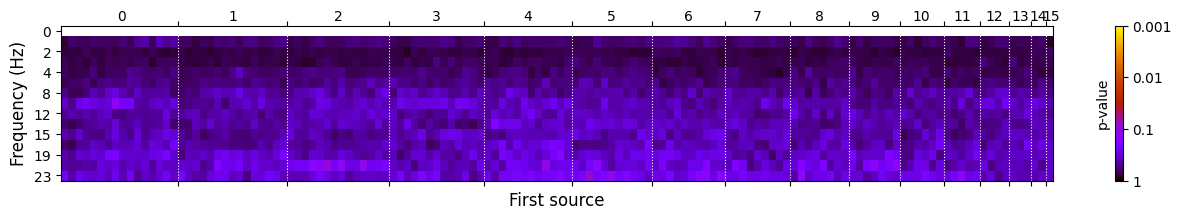

In [329]:
matshow(-log10(vec_m), vmin=0, vmax=3, cmap='gnuplot');
axis("auto")
src1 = np.array([k.src1 for k in keys[0]])
assert list(src1) == sorted(src1)
unique_src1 = sorted(np.unique(src1))
axis('auto')

xt_loc = np.where(np.diff(src1) > 0)[0] + 0.5
# I don't want the major ticks to be labeld, so I'll set the labels to empty strings.
xt_loc1 = np.array([0] + list(xt_loc) + [len(src1)])
midpoints = (xt_loc1[1:] + xt_loc1[:-1]) / 2
xticks(xt_loc, [""]*len(xt_loc))
for i, mid in enumerate(midpoints):
    text(mid, -1, f"{unique_src1[i]:g}", ha='center', fontsize=10)
xlabel(f"Conditioning source", fontsize=12)
# Turn the grid on, but only for the x-ticks, and using a dotted line.
grid(axis='x', linestyle=':', color='w')

yt = gca().get_yticks()
yt = yt[(0 <= yt)* (yt< len(ifreqs))]
yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
yticks(yt, yt_freqs)
ylabel("Frequency (Hz)", fontsize=12)

cax = colorbar().ax
yt = cax.get_yticks()
print(yt)
cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
cax.set_ylabel("p-value")
# Set the position of the label to the left of the colorbar
cax.yaxis.set_label_position('left')
savefig("figs/cond_gauss_multi.png", dpi=300, bbox_inches='tight')


# The End